# Notebook for tuning the PWAT + z500 SOM

### This notebook simply runs thru a small grid of hyperparameters that are reasonable for the relatively small nature of timesteps we are using for this project. The winner is then saved. This is done to find the "best" combination of hyperparameters (without going overboard given how insaely slow Triton takes to train a SOM), which subsequently minimizes quantization error.

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from minisom import MiniSom

from pathlib import Path
import zipfile, re, shutil
from glob import glob
from tqdm.auto import tqdm

### Per usual, opening the dataset and preparing all of the variables

In [3]:
ds = xr.open_dataset("/home/scratch/jtoniolo/483/ERA5_vars.nc")
print(ds)
print(list(ds.data_vars))

<xarray.Dataset>
Dimensions:         (valid_time: 999, latitude: 133, longitude: 241,
                     pressure_level: 2)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 2020-01-02T09:00:00 ... 2025-...
  * latitude        (latitude) float64 53.0 52.75 52.5 52.25 ... 20.5 20.25 20.0
  * longitude       (longitude) float64 -125.0 -124.8 -124.5 ... -65.25 -65.0
  * pressure_level  (pressure_level) float64 850.0 500.0
Data variables:
    tcwv            (valid_time, latitude, longitude) float32 ...
    cape            (valid_time, latitude, longitude) float32 ...
    msl             (valid_time, latitude, longitude) float32 ...
    tp              (valid_time, latitude, longitude) float32 ...
    z850            (valid_time, latitude, longitude) float32 ...
    z500            (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:       

In [4]:
ds

<xarray.Dataset>
Dimensions:         (valid_time: 999, latitude: 133, longitude: 241,
                     pressure_level: 2)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 2020-01-02T09:00:00 ... 2025-...
  * latitude        (latitude) float64 53.0 52.75 52.5 52.25 ... 20.5 20.25 20.0
  * longitude       (longitude) float64 -125.0 -124.8 -124.5 ... -65.25 -65.0
  * pressure_level  (pressure_level) float64 850.0 500.0
Data variables:
    tcwv            (valid_time, latitude, longitude) float32 ...
    cape            (valid_time, latitude, longitude) float32 ...
    msl             (valid_time, latitude, longitude) float32 ...
    tp              (valid_time, latitude, longitude) float32 ...
    z850            (valid_time, latitude, longitude) float32 ...
    z500            (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-27T22:22 GRIB to CDM+CF via cfgrib-0.9.1...

In [5]:
g0 = 9.80665
ds['z500'] = ds['z500'] / g0
ds['z500'].attrs['units'] = 'm' 

In [6]:
ds = ds.rename({'tcwv':'pwat'})
ds['pwat'].attrs['units'] = 'mm' 

In [7]:
z500 = ds['z500'].values
pwat = ds['pwat'].values

N, ny, nx = z500.shape
P = ny * nx

X = np.concatenate([z500.reshape(N, P), pwat.reshape(N, P)], axis=1) 
print(X.shape)

(999, 64106)


In [8]:
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

### Creating a grid of parameters to loop through. The QE for each combination is added to an array which is then used to save into a csv. Results are also printed below.

In [18]:
params = {
    'map':[(4,4),(5,4)],
    'sigma':[1,1.5,2],
    'learning_rate':[0.05,0.1,0.15],
    'num_iterations':[5000,7500]
}
seed = 420
grid_results = []
run = 0

for m, n in params['map']:
    for sigma in params['sigma']:
        for learning_rate in params['learning_rate']:
            for num_iterations in params['num_iterations']:

                som = MiniSom(
                    x=m,
                    y=n,
                    input_len=Xz.shape[1],
                    sigma=sigma,
                    learning_rate=learning_rate,
                    neighborhood_function='gaussian',
                    random_seed=seed
                )

                som.random_weights_init(Xz)
                som.train_random(Xz, num_iterations, verbose=False)

                bmus = np.array([som.winner(x) for x in Xz])

                counts = np.zeros((m, n), dtype=int)
                for r, c in bmus:
                    counts[r, c] += 1

                qe = som.quantization_error(Xz)

                grid_results.append({
                    'm': m,
                    'n': n,
                    'sigma': sigma,
                    'learning_rate': learning_rate,
                    'num_iterations': num_iterations,
                    'quantization_error': qe,
                })
                run += 1
                print(f'Run number: {run}')

df_results = pd.DataFrame(grid_results)
df_results = df_results.sort_values(by='quantization_error',ascending=True)
print(df_results)
df_results.to_csv("/home/z2044621/som_tuning_results.csv", index=False)

Run number: 1
Run number: 2
Run number: 3
Run number: 4
Run number: 5
Run number: 6
Run number: 7
Run number: 8
Run number: 9
Run number: 10
Run number: 11
Run number: 12
Run number: 13
Run number: 14
Run number: 15
Run number: 16
Run number: 17
Run number: 18
Run number: 19
Run number: 20
Run number: 21
Run number: 22
Run number: 23
Run number: 24
Run number: 25
Run number: 26
Run number: 27
Run number: 28
Run number: 29
Run number: 30
Run number: 31
Run number: 32
Run number: 33
Run number: 34
Run number: 35
Run number: 36
    m  n  sigma  learning_rate  num_iterations  quantization_error
20  5  4    1.0           0.10            5000          155.571027
18  5  4    1.0           0.05            5000          155.653014
23  5  4    1.0           0.15            7500          155.895482
21  5  4    1.0           0.10            7500          155.930304
19  5  4    1.0           0.05            7500          156.132248
22  5  4    1.0           0.15            5000          156.223375


### Training the winning SOM, then saving it to use again later so we no longer have to train it every single time.

In [9]:
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# NEW SOM hyperparams
m, n = 5, 4
sigma = 1.0
learning_rate = 0.1
num_iterations = 5000
seed = 420

# training the SOM
som = MiniSom(
    x=m,
    y=n,
    input_len=Xz.shape[1],
    sigma=sigma,
    learning_rate=learning_rate,
    neighborhood_function='gaussian',
    random_seed=seed
)

som.random_weights_init(Xz)
som.train_random(Xz, num_iterations, verbose=True)

bmus = np.array([som.winner(x) for x in Xz])
print("BMU shape:", bmus.shape)

node_index = bmus[:,0] * n + bmus[:,1] 

 [ 5000 / 5000 ] 100% - 0:00:00 left 
 quantization error: 155.57102681784968
BMU shape: (999, 2)


### Saving the SOM, scaler used in the SOM, as well as the BMUs using pickle

Pickle essentially turns a more complex python object into a bytestream so that objects that may take some time to compute can be stored and brought back instantly later for analysis. While our SOM isn't computationally expensive or very time consuming, it is good practice and reduces redundancies.

In [10]:
import pickle

save_dict = {'som':som, 'scaler':scaler, 'bmus':bmus}

with open('/home/scratch/jtoniolo/483/pwat_z500_som.pkl', 'wb') as f:
    pickle.dump(save_dict, f)

### Finally, a quick visualization of what affected (or didn't affect) the SOM's performance by comparing each hyperparameter to the quantization error using boxplots.

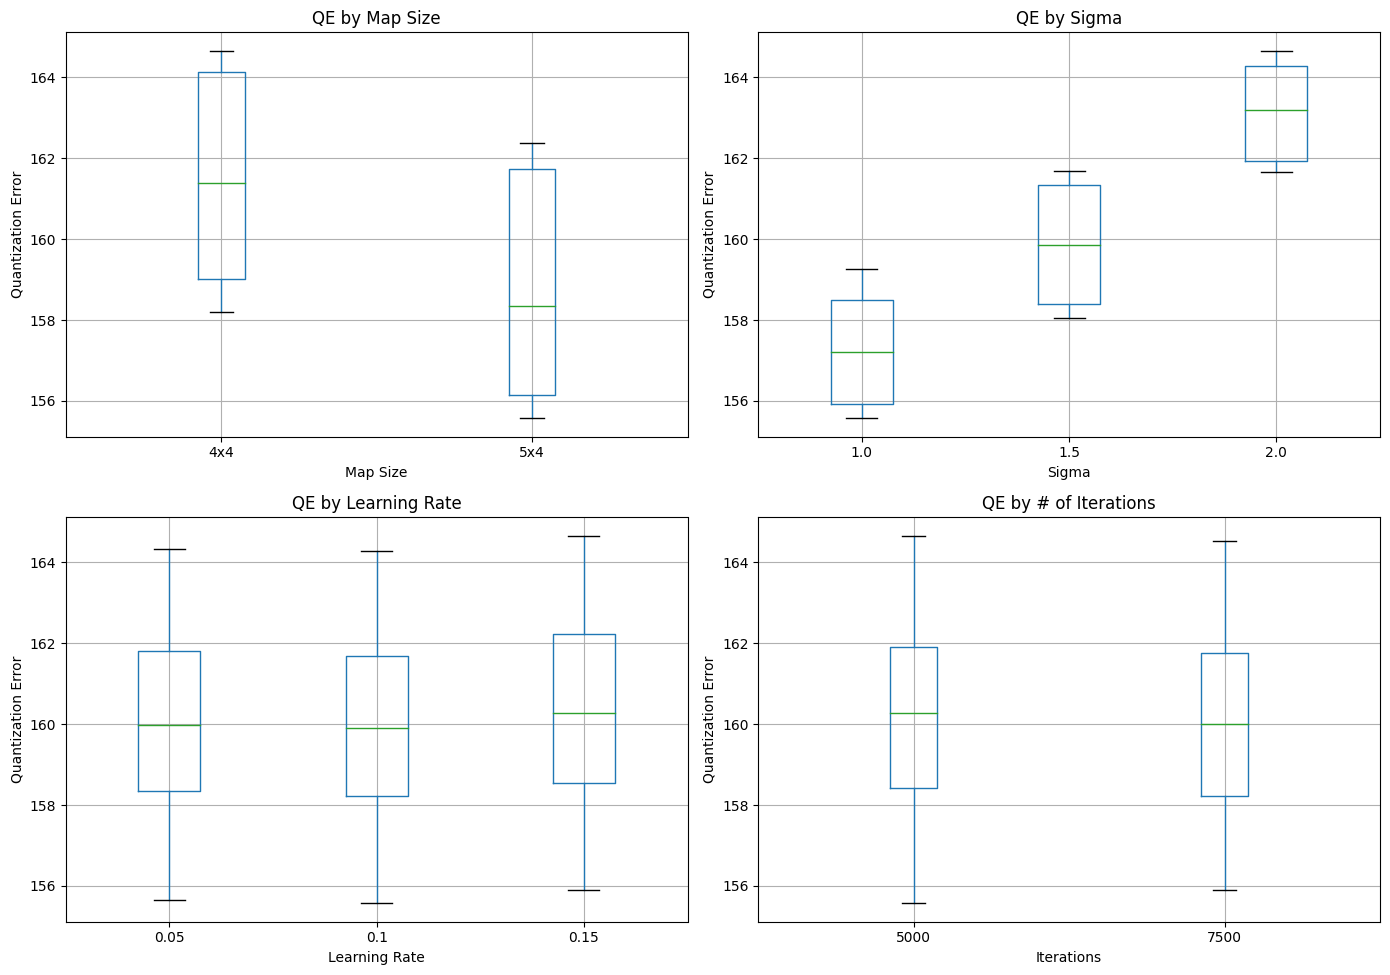

In [13]:
df = pd.read_csv("som_tuning_results.csv")

df["map_size"] = df["m"].astype(str) + "x" + df["n"].astype(str)

fig = plt.figure(figsize=(14, 10))

ax1 = plt.subplot(2, 2, 1)
df.boxplot(column="quantization_error", by="map_size", ax=ax1)
ax1.set_title("QE by Map Size")
ax1.set_xlabel("Map Size")
ax1.set_ylabel("Quantization Error")

ax2 = plt.subplot(2, 2, 2)
df.boxplot(column="quantization_error", by="sigma", ax=ax2)
ax2.set_title("QE by Sigma")
ax2.set_xlabel("Sigma")
ax2.set_ylabel("Quantization Error")

ax3 = plt.subplot(2, 2, 3)
df.boxplot(column="quantization_error", by="learning_rate", ax=ax3)
ax3.set_title("QE by Learning Rate")
ax3.set_xlabel("Learning Rate")
ax3.set_ylabel("Quantization Error")

ax4 = plt.subplot(2, 2, 4)
df.boxplot(column="quantization_error", by="num_iterations", ax=ax4)
ax4.set_title("QE by # of Iterations")
ax4.set_xlabel("Iterations")
ax4.set_ylabel("Quantization Error")

plt.suptitle("")
plt.tight_layout()
plt.show()